In [ ]:
!pip install nltk scikit-learn pandas numpy

**Import Libraries**

In [ ]:
# Import basic libraries
import pandas as pd
import numpy as np

# NLP libraries
import re
import nltk

# Download stopwords
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
df = pd.read_csv("IMDB Dataset.csv")

# Show first 5 rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Data Understanding**

In [ ]:
# Check dataset info
df.info()

# Check shape (rows, columns)
print("Shape:", df.shape)

# Check class distribution
print(df['sentiment'].value_counts())

# See few random samples
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20942 entries, 0 to 20941
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     20942 non-null  object
 1   sentiment  20942 non-null  object
dtypes: object(2)
memory usage: 327.3+ KB
Shape: (20942, 2)
sentiment
negative    10560
positive    10382
Name: count, dtype: int64


,review,sentiment
8113,What starts out as an interesting story quickl...,negative
17374,'The English Patient' is a love story set in E...,positive
14746,The first film was quite hip and had amusing m...,negative
5491,The murder of the Red Comyn in Grayfriars Abbe...,negative
17905,I truly enjoyed this film. The acting was terr...,positive


**NLP Preprocessing**

In [ ]:
# Initialize tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Preprocessing function
def preprocess_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+', '', text)

    # 3. Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenization (split into words)
    words = text.split()

    # 6. Remove stopwords + apply stemming
    cleaned_words = []
    for word in words:
        if word not in stop_words:
            stem_word = stemmer.stem(word)
            cleaned_words.append(stem_word)

    # 7. Join back into sentence
    return " ".join(cleaned_words)

**Apply Preprocessing**

In [ ]:
# Apply preprocessing to text column
df['cleaned_text'] = df['review'].apply(preprocess_text)

# Check result
df[['review', 'cleaned_text']].head()

,review,cleaned_text
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


# **Feature Engineering**

**Bag of Words (BoW)**

In [26]:
bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df['cleaned_text']).toarray()

**TF-IDF**

In [29]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['cleaned_text']).toarray()

In [30]:
y = df['sentiment']

**Train-Test Split**

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# **Train Models**

**Logistic Regression**

In [35]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**Naive Bayes**

In [39]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

**Decision Tree**

In [41]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

**Evaluation**

In [49]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Naive Bayes", y_test, y_pred_nb)
evaluate_model("Decision Tree", y_test, y_pred_dt)


Logistic Regression Results:
Accuracy: 0.8751492002864646
              precision    recall  f1-score   support

    negative       0.88      0.87      0.87      2080
    positive       0.87      0.88      0.88      2109

    accuracy                           0.88      4189
   macro avg       0.88      0.88      0.88      4189
weighted avg       0.88      0.88      0.88      4189


Naive Bayes Results:
Accuracy: 0.8555741227023156
              precision    recall  f1-score   support

    negative       0.85      0.87      0.86      2080
    positive       0.86      0.85      0.86      2109

    accuracy                           0.86      4189
   macro avg       0.86      0.86      0.86      4189
weighted avg       0.86      0.86      0.86      4189


Decision Tree Results:
Accuracy: 0.7087610408211984
              precision    recall  f1-score   support

    negative       0.71      0.71      0.71      2080
    positive       0.71      0.71      0.71      2109

    accuracy       

**Comparison & Insights**
- Logistic Regression performed best due to linear nature of text data
- Naive Bayes worked well because of probability assumptions
- Decision Tree overfitted slightly
- TF-IDF gave better results than BoW because it captures importance

In [53]:
# Compare accuracy
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("NB Accuracy:", accuracy_score(y_test, y_pred_nb))
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

LR Accuracy: 0.8751492002864646
NB Accuracy: 0.8555741227023156
DT Accuracy: 0.7087610408211984


In [56]:
# Train-test split for BoW
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

# Logistic Regression with BoW
lr_bow = LogisticRegression()
lr_bow.fit(X_train_bow, y_train)

y_pred_lr_bow = lr_bow.predict(X_test_bow)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [60]:
results = {}

# TF-IDF results
results['LR_TFIDF'] = accuracy_score(y_test, y_pred_lr)
results['NB_TFIDF'] = accuracy_score(y_test, y_pred_nb)
results['DT_TFIDF'] = accuracy_score(y_test, y_pred_dt)

# BoW result
results['LR_BOW'] = accuracy_score(y_test, y_pred_lr_bow)

print(results)

{'LR_TFIDF': 0.8751492002864646, 'NB_TFIDF': 0.8555741227023156, 'DT_TFIDF': 0.7087610408211984, 'LR_BOW': 0.8579613272857484}


**Graphical Visualization**

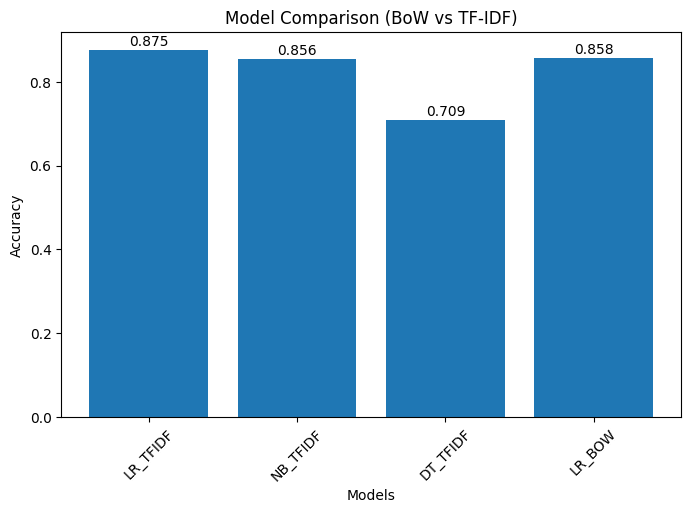

In [66]:
import matplotlib.pyplot as plt

# Names and values
models = list(results.keys())
scores = list(results.values())

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(models, scores)

# Labels
plt.title("Model Comparison (BoW vs TF-IDF)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Rotate labels for better visibility
plt.xticks(rotation=45)

# Show values on top
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')

plt.show()

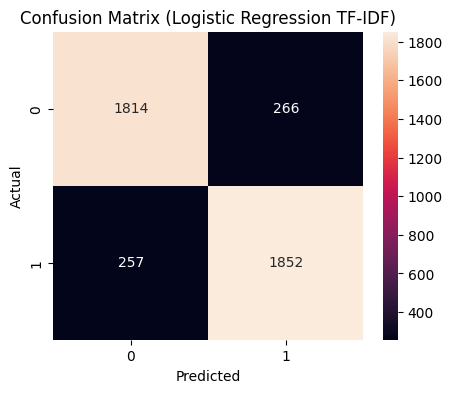

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()